In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [26]:
# READ DATASET
df = pd.read_csv("student_performance.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (200, 6)
   study_hours  attendance  assignments  previous_score  sleep_hours  Result
0            7          50            8              50            8       0
1            4          60            4              99            5       1
2            8          77            0              76            8       1
3            5          74            9              75            5       1
4            7          99            9              74            8       1


In [27]:
X = df.drop("Result", axis=1)
y = df["Result"]

In [28]:
def run_knn(test_size):
    print(f"\n--- Split Ratio {int((1-test_size)*100)}:{int(test_size*100)} ---")


    # TRAIN-TEST SPLIT
   
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # KNN 
    model = KNeighborsClassifier(n_neighbors=5)

    
    # TRAIN & PREDICT
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # EVALUATION
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)

    return acc, prec, rec, f1

results = {}

results["70:30"] = run_knn(0.3)
results["60:40"] = run_knn(0.4)
results["80:20"] = run_knn(0.2)



--- Split Ratio 70:30 ---
Accuracy: 0.9
Precision: 0.9259259259259259
Recall: 0.8620689655172413
F1 Score: 0.8928571428571429
Confusion Matrix:
 [[29  2]
 [ 4 25]]

--- Split Ratio 60:40 ---
Accuracy: 0.9375
Precision: 0.9459459459459459
Recall: 0.9210526315789473
F1 Score: 0.9333333333333333
Confusion Matrix:
 [[40  2]
 [ 3 35]]

--- Split Ratio 80:20 ---
Accuracy: 0.9
Precision: 0.8947368421052632
Recall: 0.8947368421052632
F1 Score: 0.8947368421052632
Confusion Matrix:
 [[19  2]
 [ 2 17]]


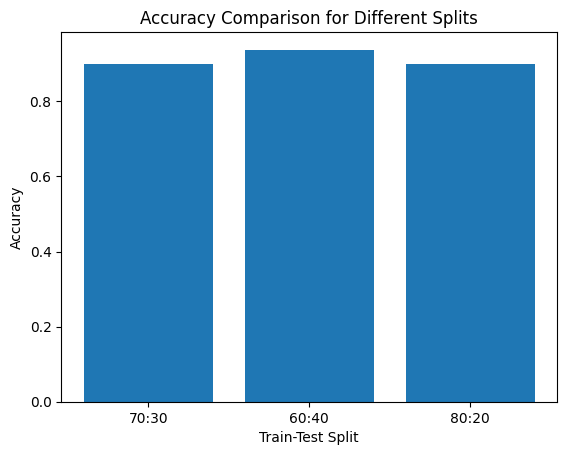

In [29]:
labels = list(results.keys())
accuracy = [results[k][0] for k in labels]

plt.figure()
plt.bar(labels, accuracy)
plt.title("Accuracy Comparison for Different Splits")
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy")
plt.show()

In [30]:
print("\n--- Prediction on New Data ---")

new_data = [[5, 50, 7, 80, 10]] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Prediction (0=Fail, 1=Pass):", prediction[0])


--- Prediction on New Data ---
Prediction (0=Fail, 1=Pass): 1
